# EDA
Etapa exploratoria post limpieza y validación de datos.

In [1]:
from notebook_utils import ensure_repo_root

# Establish the repository root as the working directory for this notebook
ensure_repo_root()

WindowsPath('C:/Github/NTR-Arogyaseva-analysis')

In [2]:
from src.utils.io import load_data, set_pandas_display_options

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Establecer opciones de visualización para pandas
set_pandas_display_options()

# Importar el dataset
df = load_data(stage="clean")

In [3]:
df.set_index("", inplace=True)

## Mortalidad

In [4]:
df["mortality y / n"].value_counts()

mortality y / n
no     469566
yes     10122
Name: count, dtype: int64

In [5]:
df["mortality"] = df["mortality y / n"].map({"yes": 1, "no": 0})

### Mortalidad vs is_child

In [6]:
childs = df[df["is_child"]].copy()
adults = df[~df["is_child"]].copy()
print("Número de filas en el dataset original:", df.shape[0])
print("Número de filas con edad <= 14 (niños):", childs.shape[0])
print("Número de filas con edad > 14 (adultos):", adults.shape[0])

Número de filas en el dataset original: 479688
Número de filas con edad <= 14 (niños): 39994
Número de filas con edad > 14 (adultos): 439694


In [7]:
subsets = {
    "Total": df,
    "Adultos (edad > 14)": adults,
    "Niños (edad <= 14)": childs,
}

In [8]:
mortality_childs_vs_adults = pd.DataFrame({
        "subset": subsets.keys(),
        "n_rows": [subset.shape[0] for subset in subsets.values()],
        "mortality_count": [subset["mortality"].sum() for subset in subsets.values()],
        "mortality_pct": [subset["mortality"].mean()*100 for subset in subsets.values()],
})
mortality_childs_vs_adults

,subset,n_rows,mortality_count,mortality_pct
0,Total,479688,10122,2.1101
1,Adultos (edad > 14),439694,9082,2.0655
2,Niños (edad <= 14),39994,1040,2.6004


mortalidad en niños ligeramente mayor que en adultos, e incluso más alta que el promedio general

### Mortalidad vs edad

In [9]:

df["age_group"] = pd.cut(
    df["age"],
    bins=[-1, 5, 11, 18, 30, 60, 80, np.inf],
    labels=["0-5", "6-11", "12-18", "19-30", "31-60", "61-80", "80+"]
)

In [10]:
mortality_by_age_group = df.groupby("age_group", observed=True)["mortality"].agg(["count", "sum", "mean"]).reset_index()
mortality_by_age_group.rename(columns={"count": "n_rows", "sum": "mortality_count", "mean": "mortality_pct"}, inplace=True)
mortality_by_age_group["mortality_pct"] *= 100
mortality_by_age_group

,age_group,n_rows,mortality_count,mortality_pct
0,0-5,27130,946,3.4869
1,6-11,7668,46,0.5999
2,12-18,14528,177,1.2183
3,19-30,48873,676,1.3832
4,31-60,280059,5255,1.8764
5,61-80,98298,2900,2.9502
6,80+,3132,122,3.8953


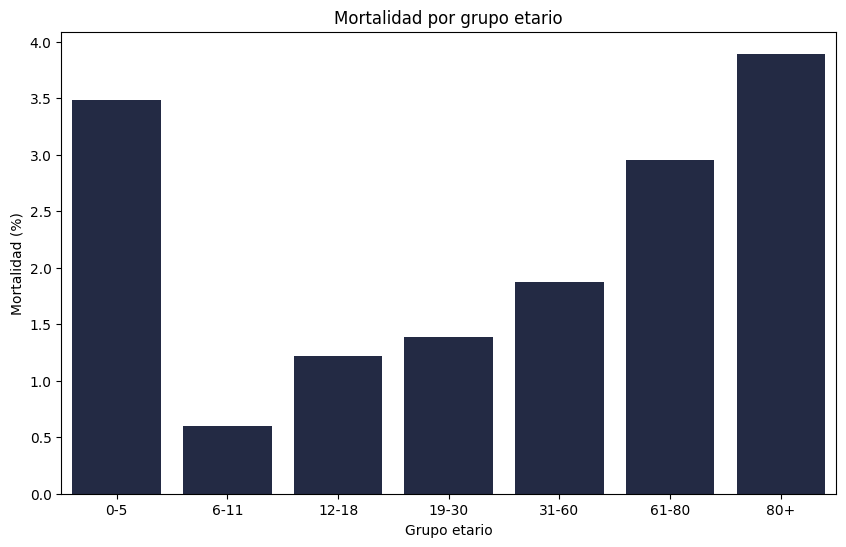

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=mortality_by_age_group, x="age_group", y="mortality_pct", color="#1E2749")
plt.title("Mortalidad por grupo etario")
plt.xlabel("Grupo etario")
plt.ylabel("Mortalidad (%)")
plt.savefig("figures/01_mortalidad_por_grupo_etario.png", bbox_inches="tight")
plt.show()


alta mortalidad en recién nacidos y adultos mayores. comportamiento ascendente desde niñez, donde se observan los valores más bajos de tasa de mortalidad con `0,6 %`

### Mortalidad vs edad y sexo

In [12]:
mortality_by_age_group_and_sex = df.groupby(["age_group", "sex"], observed=True)["mortality"].agg(["count", "sum", "mean"]).reset_index()
mortality_by_age_group_and_sex.rename(columns={"count": "n_rows", "sum": "mortality_count", "mean": "mortality_pct"}, inplace=True)
mortality_by_age_group_and_sex["mortality_pct"] *= 100
mortality_by_age_group_and_sex

,age_group,sex,n_rows,mortality_count,mortality_pct
0,0-5,female,10715,344,3.2105
1,0-5,male,16415,602,3.6674
2,6-11,female,2588,23,0.8887
3,6-11,male,5080,23,0.4528
4,12-18,female,4258,88,2.0667
5,12-18,male,10270,89,0.8666
6,19-30,female,14727,277,1.8809
7,19-30,male,34146,399,1.1685
8,31-60,female,119331,1755,1.4707
9,31-60,male,160728,3500,2.1776


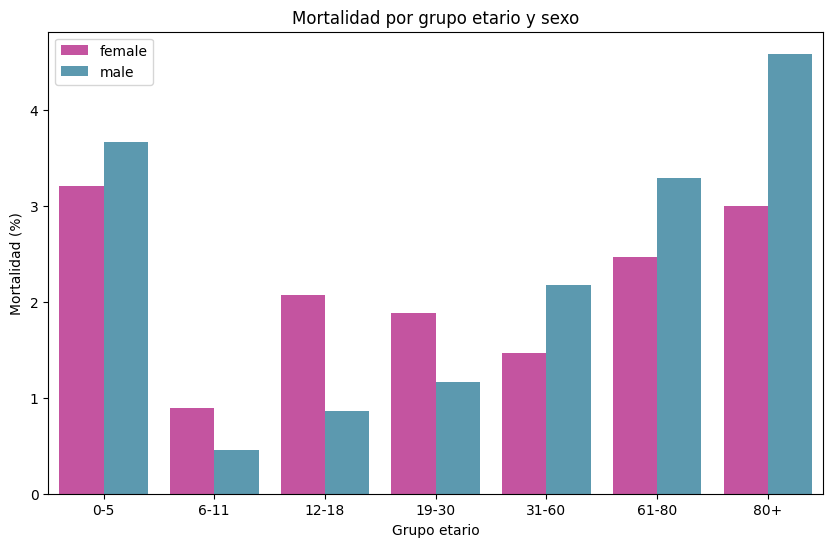

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=mortality_by_age_group_and_sex, x="age_group", y="mortality_pct", hue="sex", palette={"female": "#D741A7", "male": "#4E9FBD"})
plt.title("Mortalidad por grupo etario y sexo")
plt.xlabel("Grupo etario")
plt.ylabel("Mortalidad (%)")
plt.legend()
plt.savefig("figures/02_mortalidad_por_grupo_etario_y_sexo.png", bbox_inches="tight")
plt.show()

En recién nacidos y niñez se observan las menores discrepancias, con valores de `~0,4` puntos porcentuales, primero con sexo masculino por encima del femenino, y al contrario en el grupo de niñez. Es en este grupo donde comienza a aumentar sustancialmente la tasa de mortalidad en el sexo femenino, alcanzando un pico en el grupo de adolescencia, donde se observa un porcentaje de mortalidad de `2,07 %`. En contraste, el sexo masculino contempla un aumento sostenido, pero por debajo de su contraparte, tomando valores desde `0,45 %` hasta `1,17 %`. 

Esta situación se revierte al alcanzar la adultez, donde el sexo femenino tiene un mínimo local, alrededor del `1,47 %`, siendo superado por el sexo masculino, que continua ampliando la diferencia hasta alcanzar el máximo absoluto a nivel general, con una tasa de mortalidad de `4,59 %`, mientras que, en el otro grupo, se observa una tasa del `3,00 %`.

a realizar: 
* analizar por qué en la niñez, adolescencia y juventud, el sexo femenino tiene tasas de mortaliadad más elevadas, para luego tener una baja en la adultez, donde los hombres comienzan a tener tasas de mortalidad más altas, incluso hasta en las edades más altas observadas en el dataset
* indagar en categorías de cirugías y cirugías riesgosas (relacionadas a altas tasas de mortalidad) y analizar si tienen alguna relación con o si están mas presentes en el sexo femenino

### Mortalidad vs sexo

In [14]:
mortality_by_sex = df.groupby("sex", observed=True)["mortality"].agg(["count", "sum", "mean"]).reset_index()
mortality_by_sex.rename(columns={"count": "n_rows", "sum": "mortality_count", "mean": "mortality_pct"}, inplace=True)
mortality_by_sex["mortality_pct"] *= 100
mortality_by_sex.sort_values("mortality_pct", ascending=False)

,sex,n_rows,mortality_count,mortality_pct
1,male,285795,6584,2.3037
0,female,193893,3538,1.8247


### Mortalidad vs categoría

In [15]:
mortality_by_category = df.groupby("category_name", observed=True)["mortality"].agg(["count", "sum", "mean"]).reset_index()
mortality_by_category.rename(columns={"count": "n_rows", "sum": "mortality_count", "mean": "mortality_pct"}, inplace=True)
mortality_by_category["mortality_pct"] *= 100
mortality_by_category = mortality_by_category.sort_values("mortality_pct", ascending=False)
mortality_by_category

,category_name,n_rows,mortality_count,mortality_pct
3,critical care,2321,526,22.6626
12,infectious diseases,5,1,20.0000
24,pulmonology,4630,569,12.2894
21,plastic surgery,1682,189,11.2366
15,neurology,13361,1029,7.7015
8,general medicine,1366,88,6.4422
16,neurosurgery,10917,638,5.8441
1,cardiology,18629,831,4.4608
14,nephrology,74947,2995,3.9962
7,gastroenterology,3969,141,3.5525


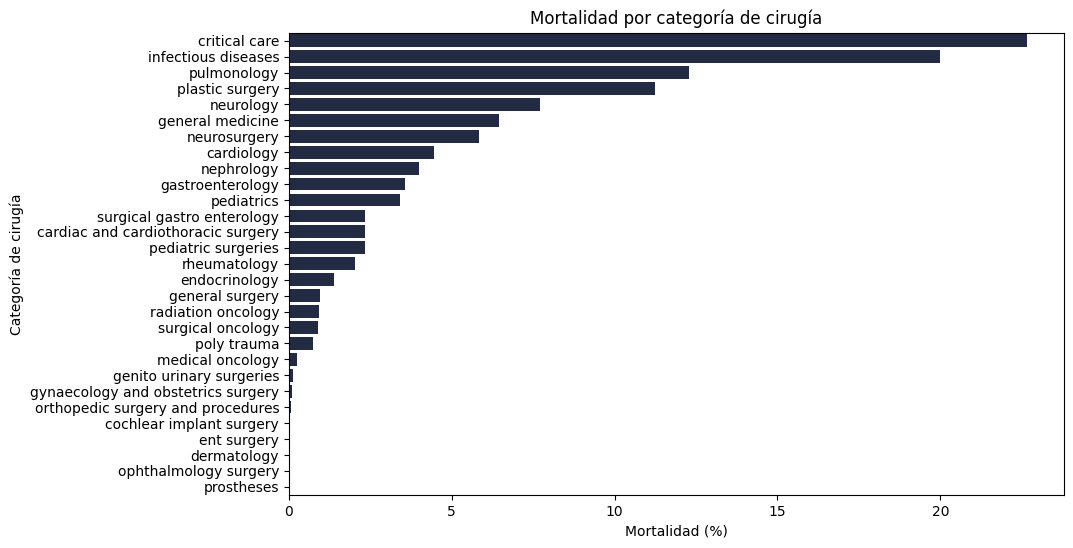

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=mortality_by_category, x="mortality_pct", y="category_name", color="#1E2749", orient="h")
plt.title("Mortalidad por categoría de cirugía")
plt.ylabel("Categoría de cirugía")
plt.xlabel("Mortalidad (%)")
plt.savefig("figures/03_mortalidad_por_categoria.png", bbox_inches="tight")
plt.show()


hay muchas categorías con tasa de mortalidad cero, que representan riesgo de mortalidad nulo. si queremos analizar los patrones de mortalidad, deberíamos contemplar la diferencia entre estas categorías

In [17]:
mean_mortality = df["mortality"].mean() * 100
print(f"Mortalidad promedio en el dataset: {mean_mortality:.2f}%")
risky_categories = mortality_by_category[mortality_by_category["mortality_pct"] > mean_mortality]
print("Categorías de cirugía con mortalidad por encima del promedio:")
print(risky_categories[["category_name", "mortality_pct"]])

Mortalidad promedio en el dataset: 2.11%
Categorías de cirugía con mortalidad por encima del promedio:
                         category_name  mortality_pct
3                        critical care        22.6626
12                 infectious diseases        20.0000
24                         pulmonology        12.2894
21                     plastic surgery        11.2366
15                           neurology         7.7015
8                     general medicine         6.4422
16                        neurosurgery         5.8441
1                           cardiology         4.4608
14                          nephrology         3.9962
7                     gastroenterology         3.5525
20                          pediatrics         3.4161
27          surgical gastro enterology         2.3360
0   cardiac and cardiothoracic surgery         2.3257
19                 pediatric surgeries         2.3233


a realizar:
* cruzar esta lista de categorías riesgosas con grupos etarios para ver si hay relación

In [18]:
mortality_by_category_and_sex = df.groupby(["category_name", "sex"], observed=True)["mortality"].agg(["count", "sum", "mean"]).reset_index()
mortality_by_category_and_sex.rename(columns={"count": "n_rows", "sum": "mortality_count", "mean": "mortality_pct"}, inplace=True)
mortality_by_category_and_sex["mortality_pct"] *= 100
mortality_by_category_and_sex = mortality_by_category_and_sex.sort_values("mortality_pct", ascending=False)
mortality_by_category_and_sex

,category_name,sex,n_rows,mortality_count,mortality_pct
6,critical care,female,752,174,23.1383
7,critical care,male,1569,352,22.4347
23,infectious diseases,male,5,1,20.0000
40,plastic surgery,female,693,129,18.6147
46,pulmonology,male,3069,388,12.6426
45,pulmonology,female,1561,181,11.5951
29,neurology,male,8493,697,8.2068
2,cardiology,female,5396,392,7.2646
17,general medicine,male,791,55,6.9532
28,neurology,female,4868,332,6.8200


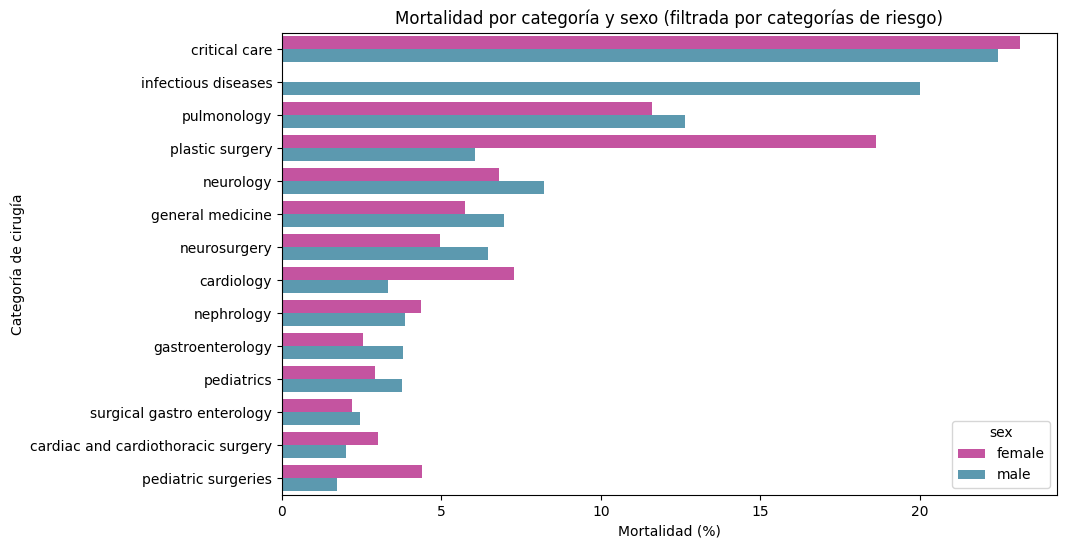

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=mortality_by_category_and_sex, 
    x="mortality_pct", 
    y="category_name", 
    hue="sex", 
    palette={"female": "#D741A7", "male": "#4E9FBD"}, 
    orient="h", 
    order=risky_categories["category_name"]
)
plt.title("Mortalidad por categoría y sexo (filtrada por categorías de riesgo)")
plt.ylabel("Categoría de cirugía")
plt.xlabel("Mortalidad (%)")
plt.savefig("figures/04_mortalidad_por_categoria_y_sexo.png", bbox_inches="tight")
plt.show()


no veo que haya una distinción clara entre las tasas de mortalidad por sexo, dentro de cada categoría de cirugía

### Mortalidad vs cirugía

In [20]:
mortality_by_surgery = df.groupby("surgery", observed=True)["mortality"].agg(["count", "sum", "mean"]).reset_index()
mortality_by_surgery.rename(columns={"count": "n_rows", "sum": "mortality_count", "mean": "mortality_pct"}, inplace=True)
mortality_by_surgery["mortality_pct"] *= 100
mortality_by_surgery = mortality_by_surgery.sort_values("mortality_pct", ascending=False).reset_index(drop=True)
mortality_by_surgery[mortality_by_surgery["n_rows"]>30].head(25)

,surgery,n_rows,mortality_count,mortality_pct
3,surgical management of above 60% mixed burns,61,57,93.4426
7,conservative management of 60% burns,88,56,63.6364
13,medical management of ards with multi organ failure (r65.1),93,44,47.3118
14,medical management of acute mi requiring iabp pump,47,22,46.8085
15,external ventricular drainage (evd),176,76,43.1818
17,medical management of acute bronchitis with pneumonia and respiratory failure,56,23,41.0714
18,surgical management of oesophageal atresia in paediatric patients,70,28,40.0000
21,medical management of acute respiratory failure (with ventilator),1118,440,39.3560
22,medical management of ards,85,33,38.8235
23,medical management of pre-term baby of <30 weeks severe hyaline membrane dis...,45,17,37.7778


### Mortalidad vs tipo de hospital

In [21]:
mortality_by_hosp_type = df.groupby("hosp_type", observed=True)["mortality"].agg(["count", "sum", "mean"]).reset_index()
mortality_by_hosp_type.rename(columns={"count": "n_rows", "sum": "mortality_count", "mean": "mortality_pct"}, inplace=True)
mortality_by_hosp_type["mortality_pct"] *= 100
mortality_by_hosp_type.sort_values("mortality_pct", ascending=False)

,hosp_type,n_rows,mortality_count,mortality_pct
1,g,110342,3994,3.6197
0,c,369346,6128,1.6591


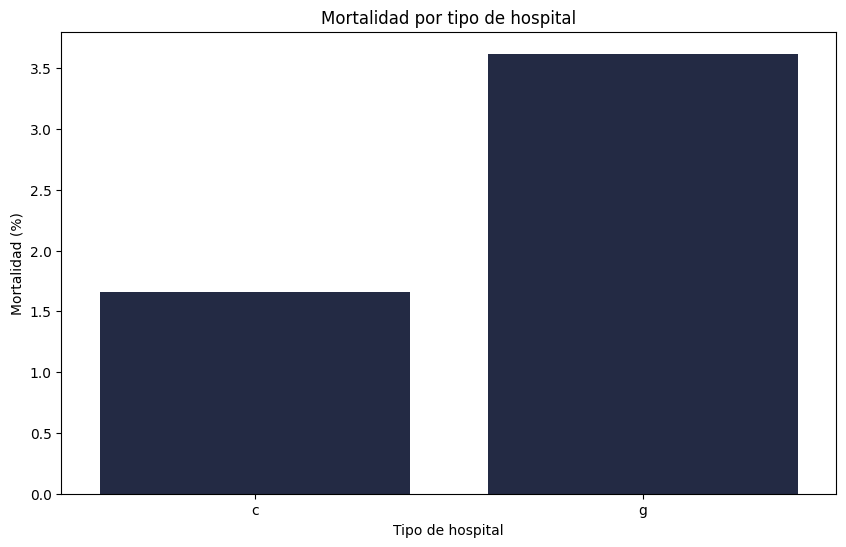

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(data=mortality_by_hosp_type, y="mortality_pct", x="hosp_type", color="#1E2749")
plt.title("Mortalidad por tipo de hospital")
plt.xlabel("Tipo de hospital")
plt.ylabel("Mortalidad (%)")
plt.savefig("figures/05_mortalidad_por_tipo_hospital.png", bbox_inches="tight")
plt.show()

### Mortalidad vs hospital

In [23]:
mortality_by_hosp = df.groupby(["hosp_name","hosp_type"], observed=True)["mortality"].agg(["count", "sum", "mean"]).reset_index()
mortality_by_hosp.rename(columns={"count": "n_rows", "sum": "mortality_count", "mean": "mortality_pct"}, inplace=True)
mortality_by_hosp["mortality_pct"] *= 100
mortality_by_hosp = mortality_by_hosp.sort_values("mortality_pct", ascending=False).reset_index(drop=True)
mortality_by_hosp[mortality_by_hosp["n_rows"]>30].head(20)

,hosp_name,hosp_type,n_rows,mortality_count,mortality_pct
6,aims for child health,c,200,22,11.0000
7,rainbow institute of child health and maternity hospital,c,91,9,9.8901
9,mamatha general and super speciality hospital a unit of mamatha educational ...,c,45,4,8.8889
10,district hospital-khammam-,g,69,6,8.6957
11,gsl medical college and gsl general hospital,c,1921,162,8.4331
12,kamalakar hospital,c,440,37,8.4091
13,abhaya kidney care mulityspeciality hospital,c,799,67,8.3855
15,pes institute of medical sciences and research hospital,c,2427,185,7.6226
16,govt general hospital kurnool,g,10250,770,7.5122
17,andhra health diagnostic services limitedglobal vijayawada,c,1292,93,7.1981


### Mortalidad vs categoría de cirugía por tipo de hospital

In [24]:
mortality_by_category_and_hosp_type = df.groupby(["category_name", "hosp_type"], observed=True)["mortality"].agg(["count", "sum", "mean"]).reset_index()
mortality_by_category_and_hosp_type.rename(
    columns={"count": "n_rows", "sum": "mortality_count", "mean": "mortality_pct"},
    inplace=True,
)
category_pct_map = mortality_by_category.set_index("category_name")["mortality_pct"]
mortality_by_category_and_hosp_type["diff"] = (
    mortality_by_category_and_hosp_type["mortality_pct"] * 100
    - mortality_by_category_and_hosp_type["category_name"].map(category_pct_map)
)
mortality_by_category_and_hosp_type["mortality_pct"] *= 100
mortality_by_category_and_hosp_type =mortality_by_category_and_hosp_type.sort_values("mortality_pct", ascending=False)

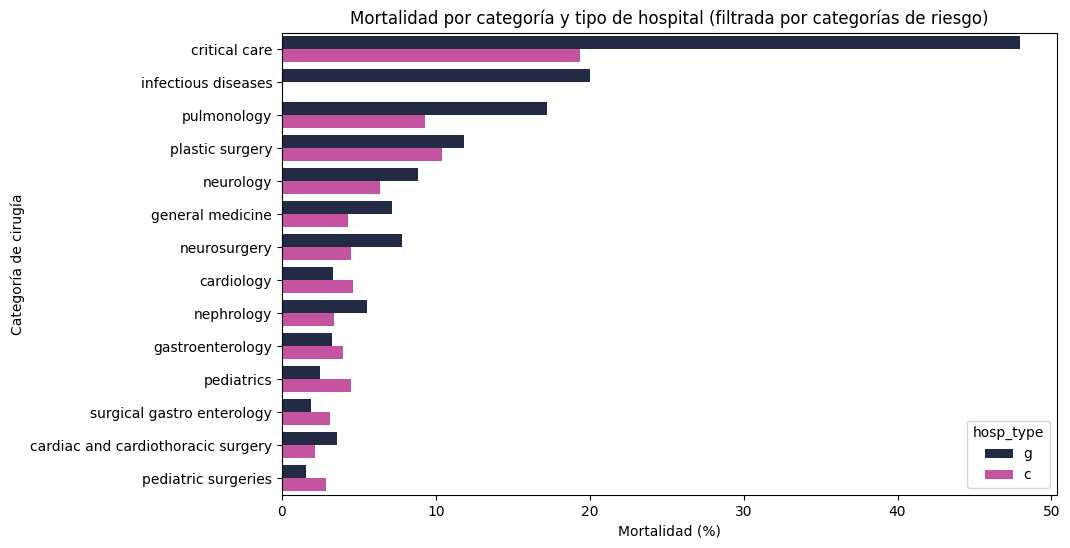

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=mortality_by_category_and_hosp_type, 
    x="mortality_pct", 
    y="category_name", 
    hue="hosp_type", 
    palette={"g": "#1E2749", "c": "#D741A7"}, 
    orient="h", 
    order=risky_categories["category_name"]
)
plt.title("Mortalidad por categoría y tipo de hospital (filtrada por categorías de riesgo)")
plt.ylabel("Categoría de cirugía")
plt.xlabel("Mortalidad (%)")
plt.savefig("figures/06_mortalidad_por_categoria_y_tipo_hospital.png", bbox_inches="tight")
plt.show()

### Mortalidad vs distrito del paciente

In [ ]:
mortality_by_district = df.groupby("district_name", observed=True)["mortality"].agg(["count", "sum", "mean"]).reset_index()
mortality_by_district.rename(columns={"count": "n_rows", "sum": "mortality_count", "mean": "mortality_pct"}, inplace=True)
mortality_by_district["mortality_pct"] *= 100
mortality_by_district = mortality_by_district.sort_values("mortality_pct", ascending=False)
mortality_by_district

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=mortality_by_district.head(20), 
        x="mortality_pct", 
        y="district_name",
        orient="h"
)
plt.title("Mortalidad por distrito del paciente")
plt.ylabel("Distrito del paciente")
plt.xlabel("Mortalidad (%)")
plt.savefig("figures/07_mortalidad_por_distrito_del_paciente.png", bbox_inches="tight")
plt.show()

## Pre-Auth Amount

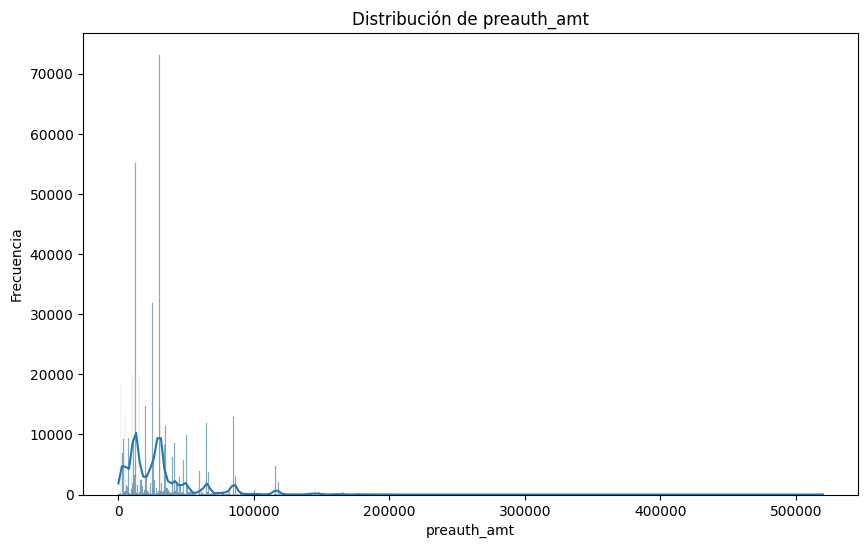

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(df, x="preauth_amt", kde=True)
plt.title("Distribución de preauth_amt")
plt.xlabel("preauth_amt")
plt.ylabel("Frecuencia")
plt.savefig("figures/07_distribucion_preauth_amt.png", bbox_inches="tight")
plt.show()

In [27]:
df["log_preauth_amt"] = np.log10(df["preauth_amt"])
mortality_yes = df[df["mortality"] == 1]
mortality_no = df[df["mortality"] == 0]

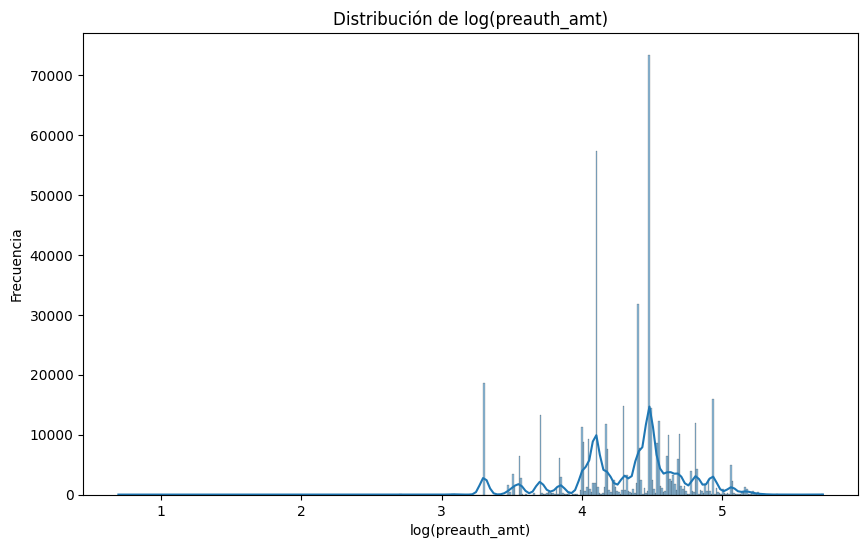

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df, x="log_preauth_amt", kde=True)
plt.title("Distribución de log(preauth_amt)")
plt.xlabel("log(preauth_amt)")
plt.ylabel("Frecuencia")
plt.savefig("figures/08_distribucion_log_preauth_amt.png", bbox_inches="tight")
plt.show()


### Pre-Auth amount por mortalidad

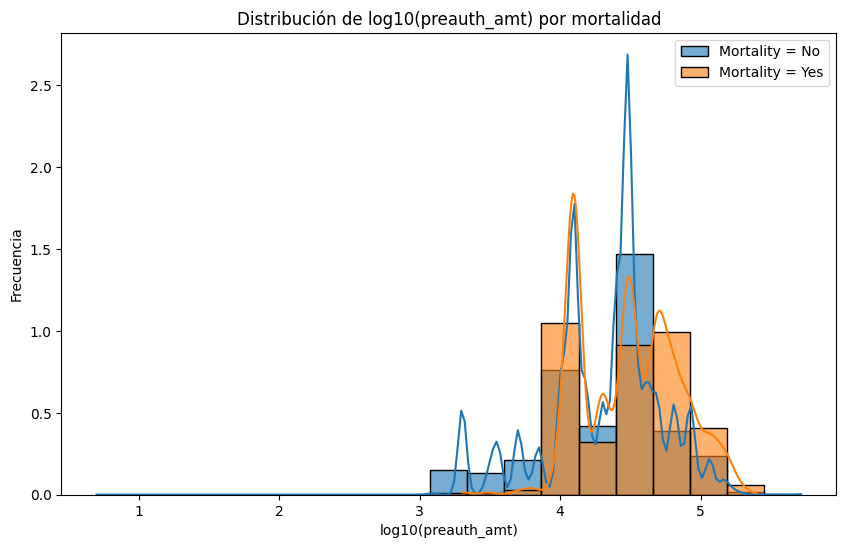

In [29]:
bins = np.linspace(df["log_preauth_amt"].min(), df["log_preauth_amt"].max(), 20)
plt.figure(figsize=(10, 6))
sns.histplot(data=mortality_no, x="log_preauth_amt", bins=bins, kde=True, label="Mortality = No", stat="density", alpha=0.6)
sns.histplot(data=mortality_yes, x="log_preauth_amt", bins=bins, kde=True, label="Mortality = Yes", stat="density", alpha=0.6)
plt.title("Distribución de log10(preauth_amt) por mortalidad")
plt.xlabel("log10(preauth_amt)")
plt.ylabel("Frecuencia")
plt.legend()
plt.savefig("figures/09_distribucion_log_preauth_amt_por_mortalidad.png", bbox_inches="tight")
plt.show()

In [30]:
preauth_amt_stats = pd.DataFrame({})
preauth_amt_stats["Total"] = df["preauth_amt"].describe()
preauth_amt_stats["Mortality = No"] = mortality_no["preauth_amt"].describe()
preauth_amt_stats["Mortality = Yes"] = mortality_yes["preauth_amt"].describe()

In [31]:
preauth_amt_stats

,Total,Mortality = No,Mortality = Yes
count,479688.0000,469566.0000,10122.0000
mean,30428.9417,30155.6904,43105.2435
std,27441.5923,27163.9031,35950.6927
min,5.0000,5.0000,2000.0000
25%,12500.0000,12500.0000,12500.0000
50%,25000.0000,25000.0000,30870.0000
75%,35000.0000,35000.0000,60000.0000
max,520000.0000,520000.0000,249543.0000
